In [21]:
# Core Data Analysis & Computing
import numpy as np
import pandas as pd
import xarray as xr
import flox
from dask.diagnostics import ProgressBar

# Geospatial & STAC Access
import leafmap
import odc.stac
import planetary_computer
import pystac_client

# Visualization & Styling
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from IPython.display import Image

print("All libraries imported successfully!")


All libraries imported successfully!


# Workshop roadmap

The workflow below is built around one question: **Can we combine a crop map with satellite observations without first downloading complete datasets to our computer?**

We will answer that question in small steps. First we discover and inspect data through STAC. Then we stream selected raster assets as Cloud-Optimized GeoTIFFs, load them into xarray, keep the computation lazy with Dask, align different datasets on a common grid, and finally calculate a small time-series statistic.

Keep an eye on the boundary between **metadata operations** and **pixel operations**. A cloud-native workflow tries to do as much filtering and planning as possible before reading pixels. That is what makes the workflow scalable: the amount of data transferred is driven by the analysis request rather than by the size of the archive.

# Cloud-Native Remote Sensing Workflows

This workshop follows one complete cloud-native workflow from data discovery to a small scientific result. We will combine a crop-type map from the Thünen EOData STAC API with Landsat observations from Microsoft Planetary Computer, while keeping the data lazy for as long as possible.

The central idea is simple: instead of downloading complete datasets first and processing them locally, we describe what we need, let STAC help us discover the relevant assets, and then stream only the pixels required for the analysis.

By the end, we will have calculated the observed annual peak NDVI day for selected crop types in our study area. Along the way, we will see why STAC, Cloud-Optimized GeoTIFFs, xarray, Dask, and `odc.stac` work particularly well together.

## 1. Define the study area

We use a small area in Lower Saxony so that the workflow stays fast enough for a live workshop. The same code pattern can later be applied to much larger areas; the important difference is that we should then pay more attention to chunking, computation, and storage rather than changing the basic workflow.

In [22]:
start_year = 1990
end_year = 2019
time_range = f"{start_year}-01-01/{end_year}-12-31"
print("Time range:", time_range)

bbox = [8.98, 53.28, 9.08, 53.32]

m = leafmap.Map()
m.add_bbox(bbox, layer_name="Study Area", fill_opacity=0.2)
m.zoom_to_bounds(bbox)
m


Time range: 1990-01-01/2019-12-31


Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

## 2. Connect to the Thünen STAC API

STAC stands for SpatioTemporal Asset Catalog. It provides a standardized way to describe and search geospatial data without forcing us to download the data first.

The most useful mental model is **Collection → Item → Asset**. A Collection describes a dataset, an Item represents one observation or map for a particular place and time, and an Asset points to an actual resource such as a Cloud-Optimized GeoTIFF or a thumbnail.

This separation between metadata and data is one of the foundations of a cloud-native workflow. We can first ask the catalogue what exists, where it is, when it was acquired, and which files are available, and only then decide which pixels we actually need.

We first list the available collections so we can see what is on offer.

In [23]:
thuenen_eodata = pystac_client.Client.open("https://eodata.thuenen.de/stac/api/v1/")

for collection in thuenen_eodata.get_all_collections():
    print(collection.id, "-", collection.title)


crop-type-map-latest - Crop Type Map (latest)
crop-type-map-v302 - Crop Type Map (v302)
fractional-cover - Fractional Cover Time Series
grassland-use - Grassland Use Intensity
hist-crop-type-map - Historical Crop Type Maps
soil-reflectance-composite - Soil Reflectance Composite
winter-cover - Winter Cropland Cover


## 3. Search the Thünen EOData STAC API

We search the historical crop-type-map collection for our study area and the complete time period. The search combines spatial and temporal constraints, so the catalogue does the filtering before we touch any raster data.

At this point we are only retrieving **STAC metadata**, not raster pixels. This is an important distinction: searching a cloud catalogue can be extremely cheap compared with downloading and opening a complete archive.

The result is a list of STAC Items that tells us which observations are relevant to our analysis.

In [24]:
thuenen_eodata_search = thuenen_eodata.search(
    collections=["hist-crop-type-map"],
    bbox=bbox,
    datetime=time_range,
)

crop_items = list(thuenen_eodata_search.items())

print("Crop-map items:", len(crop_items))
print("Years:", [item.datetime.year for item in crop_items])


Crop-map items: 30
Years: [2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992, 1991, 1990]


### What did the STAC search return?

A STAC Item carries metadata that we can inspect without reading the raster: its date, spatial reference, resolution, available assets, and other dataset-specific information. This is useful because we can make processing decisions from metadata before spending time or bandwidth on the actual pixels.

Let's inspect one Item and look at the relationship between its metadata and its assets.

In [25]:
item = crop_items[0]

print("Item:", item.id)
print("Date:", item.datetime.date())
print("Assets:", list(item.assets))
print("EPSG:", item.properties["proj:epsg"])
print("Resolution:", item.properties["proj:transform"][0], "m")

print("\nCrop-type asset:")
print(item.assets["crop_type"].href)

print("\nThumbnail asset:")
Image(url=item.assets["thumbnail"].href, width=200)


Item: hist-crop-type-map-2019
Date: 2019-07-01
Assets: ['cso', 'crop_type', 'thumbnail']
EPSG: 3035
Resolution: 30.0 m

Crop-type asset:
https://eodata.thuenen.de/cog/hist_crop_type_map/HCTM_GER_2019_rst_v101_COG.tif

Thumbnail asset:


## 4. Derive the legend and colormap from the STAC metadata

The legend lives in the STAC Collection metadata, so no raster needs to be opened to read it. Each class contains a numeric value, a title, and a color hint.

We turn this metadata into two things. First, we create a `ListedColormap` with one position for every integer from 0 to the largest crop code. Unused codes receive a transparent color. This dense layout means that the color at position *i* corresponds directly to crop code *i*, which allows `imshow` and `geogif` to use the same colormap with simple `vmin` and `vmax` settings.

Second, we create Matplotlib legend handles from the same metadata. The important cloud-native idea here is that visualization information travels with the dataset metadata instead of being hard-coded separately in our analysis.

In [26]:
crop_legend = (
    thuenen_eodata.get_collection("hist-crop-type-map")
    .item_assets["crop_type"]
    .to_dict()["classification:classes"]
)
for entry in crop_legend:
    entry["color_hint"] = "#" + entry["color_hint"]

legend_df = pd.DataFrame(crop_legend).set_index("value")

max_code = int(legend_df.index.max())
color_by_value = dict(zip(legend_df.index, legend_df["color_hint"]))
colors = [color_by_value.get(c, "#ffffff00") for c in range(max_code + 1)]
cmap = ListedColormap(colors)

handles = [
    mpatches.Patch(color=row["color_hint"], label=f"{row['title']} ({v})")
    for v, row in legend_df.iterrows()
]

legend_df


,name,title,color_hint,description
value,,,,
110,winter-cereals,Winter cereals,#FBFB16,Winter cereals
120,summer-cereals,Summer cereals,#C24B2D,Summer cereals
130,maize,Maize,#37EDD8,Maize
200,grassland,Grassland,#69C229,Grassland
1401,potato,Potato,#C37DEE,Potato
1402,sugar-beet,Sugar beet,#9A0CEE,Sugar beet
1501,rapeseed,Rapeseed,#EE439C,Rapeseed
1502,sunflower,Sunflower,#E300F7,Sunflower
1601,legumes,Legumes,#5EB084,Legumes


## 5. Inspect a single crop map year

`odc.stac.load()` connects the STAC description to the actual raster data. It can use the asset URL stored in the Item and request only the spatial subset and resolution we need.

We will deliberately look at this in two stages. First, `odc.stac.load()` builds a description of the data we want. The resulting arrays are lazy, so this step does not immediately read all raster pixels into memory. Then we trigger the actual read by plotting the data.

This is one of the key differences from a traditional workflow based on downloading files first: the analysis describes a computation, and the data are fetched when the computation actually requires them.

In [27]:
single_crop_item = crop_items[-1]

single_crop_map = odc.stac.load(
    [single_crop_item],
    bands=["crop_type"],
    bbox=bbox,
    bbox_crs="EPSG:4326",
    crs="EPSG:3035",
    resolution=30,
    resampling="nearest",
    chunks={},
    fail_on_error=False,
)

single_crop_map


<xarray.Dataset> Size: 72kB
Dimensions:      (y: 153, x: 225, time: 1)
Coordinates:
  * y            (y) float64 1kB 3.357e+06 3.357e+06 ... 3.353e+06 3.353e+06
  * x            (x) float64 2kB 4.253e+06 4.253e+06 ... 4.26e+06 4.26e+06
  * time         (time) datetime64[us] 8B 1990-07-01
    spatial_ref  int32 4B 3035
Data variables:
    crop_type    (time, y, x) uint16 69kB dask.array<chunksize=(1, 153, 225), meta=np.ndarray>

### What just happened?

We passed a **data request** to `odc.stac.load()`.

- `bbox` and `bbox_crs` define the area we need, expressed in latitude and longitude.
- `crs="EPSG:3035"` requests ETRS89 / LAEA Europe, which is a useful projected CRS for analysis across Europe.
- `resolution=30` requests a 30 m output grid.
- `resampling="nearest"` is important for categorical data because nearest-neighbour resampling preserves the original class values instead of creating meaningless intermediate classes.

In return we get a lazy **xarray Dataset** with a `time` dimension of length 1, `x` and `y` coordinates in metres, and a `crop_type` variable containing integer class codes.

The important point is that `odc.stac.load()` is doing several pieces of geospatial plumbing for us: it reads the STAC asset information, selects the requested spatial subset, handles reprojection and resampling, and exposes the result as an xarray object. We therefore work with analysis-ready arrays instead of manually downloading, opening, warping, and aligning raster files.

The actual computation is represented as a Dask task graph and is executed when we ask for concrete values, for example by plotting or calling `.compute()`.

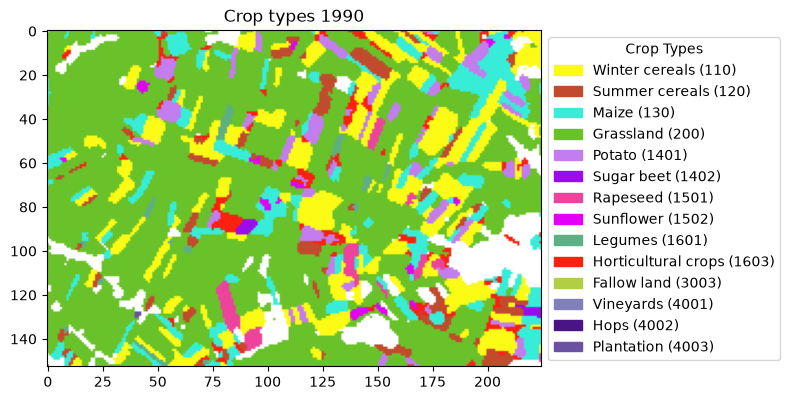

In [28]:
plt.figure(figsize=(8, 6))
plt.imshow(single_crop_map["crop_type"].isel(time=0), cmap=cmap, vmin=0, vmax=max_code)
plt.legend(handles=handles, title="Crop Types", bbox_to_anchor=(1, 1), loc="upper left")
plt.title(f"Crop types {single_crop_item.datetime.year}")
plt.tight_layout()
plt.show()


## 5.5 Load the full stack and animate it

Now we make exactly the same type of request, but for every crop-map year returned by our STAC search. This produces a time series as one xarray object.

This is where the combination of STAC, COGs, xarray, and Dask becomes particularly useful. We do not need to manually download thirty raster files, open them one by one, and build a time stack ourselves. The catalogue provides the assets, `odc.stac` turns them into a common data structure, and xarray gives us labeled time and spatial dimensions.

We then hand the cube to `geogif`, which renders the temporal dimension as an animation. The intermediate data remain in memory as arrays rather than being written to a collection of temporary raster files.

In [29]:
crop_maps = odc.stac.load(
    crop_items,
    bands=["crop_type"],
    bbox=bbox,
    bbox_crs="EPSG:4326",
    crs="EPSG:3035",
    resolution=30,
    resampling="nearest",
    chunks={},
    fail_on_error=False,
)

print(crop_maps)


<xarray.Dataset> Size: 2MB
Dimensions:      (y: 153, x: 225, time: 30)
Coordinates:
  * y            (y) float64 1kB 3.357e+06 3.357e+06 ... 3.353e+06 3.353e+06
  * x            (x) float64 2kB 4.253e+06 4.253e+06 ... 4.26e+06 4.26e+06
  * time         (time) datetime64[us] 240B 1990-07-01 1991-07-01 ... 2019-07-01
    spatial_ref  int32 4B 3035
Data variables:
    crop_type    (time, y, x) uint16 2MB dask.array<chunksize=(1, 153, 225), meta=np.ndarray>


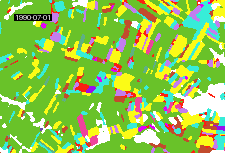

In [30]:
import geogif

gif = geogif.dgif(
    crop_maps["crop_type"],
    cmap=cmap,
    vmin=0,
    vmax=max_code,
    fps=4,
    robust=False,
    bytes=True,
).compute()

Image(gif, width=900)


### Cloud-native checkpoint

At this point we have already crossed an important conceptual boundary. We did not download a complete crop-map archive, store intermediate GeoTIFFs, or manually build a time stack. STAC described the available assets, `odc.stac` translated our request into an xarray Dataset, and Dask can defer the actual pixel reads. The same pattern becomes increasingly valuable as the study area and number of observations grow.

## 6. Connect to the Microsoft Planetary Computer STAC API

So far we have used a Thünen data product. Now we need satellite observations, so we connect to a second STAC catalogue: Microsoft Planetary Computer.

The important point is that the workflow does not depend on one particular data provider. STAC gives us a common interface for discovering datasets from different catalogues. Once we have found suitable assets, tools such as `odc.stac` can work with them using the same general loading pattern.

Planetary Computer also provides access to cloud-hosted Earth observation archives, which means we can use the same principle of requesting only the observations and pixels relevant to our analysis.

In [31]:
mpc = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)


## 7. Search Landsat Collection 2 Level-2

This collection contains atmospherically corrected surface reflectance observations from Landsat. We filter the search spatially and temporally and additionally require scenes with less than 30% reported cloud cover.

Notice the workflow pattern: **search first, load later**. The STAC search tells us which scenes are candidates. We have still not downloaded a complete Landsat archive.

The cloud-cover filter is only a first screening step. Later we will use the pixel-level `QA_PIXEL` information to remove clouds, shadows, snow, and other problematic pixels. Scene-level metadata and pixel-level quality information therefore play different roles.

In [32]:
landsat_search = mpc.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 30}},
)

landsat_items = list(landsat_search.items())

print("Landsat items:", len(landsat_items))


Landsat items: 371


## 8. Load Landsat lazily on the crop-map grid

We only need three Landsat bands for this analysis: `red`, near infrared (`nir08`), and the pixel quality mask (`qa_pixel`).

Instead of defining another bounding box, CRS, and resolution, we reuse the exact grid of the crop maps with `geobox=crop_maps.odc.geobox`. This is a powerful practical feature of `odc.stac`: once one dataset has established the analysis grid, another dataset can be loaded directly onto that same grid.

The result is that Landsat and the crop maps line up pixel-for-pixel. We avoid a separate reprojection or resampling step later, and the crop type belonging to a pixel can therefore be combined directly with the satellite-derived NDVI for that pixel.

The data remain Dask-backed and lazy. We are building the workflow first and postponing the expensive pixel reads until they are actually needed.

In [33]:
bands_to_load = ["red", "nir08", "qa_pixel"]

landsat = odc.stac.load(
    landsat_items,
    bands=bands_to_load,
    geobox=crop_maps.odc.geobox,
    resampling="nearest",
    chunks={"time": 16, "x": -1, "y": -1},
    groupby="solar_day",
    fail_on_error=False,
)

print(landsat)


<xarray.Dataset> Size: 77MB
Dimensions:      (y: 153, x: 225, time: 371)
Coordinates:
  * y            (y) float64 1kB 3.357e+06 3.357e+06 ... 3.353e+06 3.353e+06
  * x            (x) float64 2kB 4.253e+06 4.253e+06 ... 4.26e+06 4.26e+06
  * time         (time) datetime64[us] 3kB 1990-02-05T09:42:55.049000 ... 201...
    spatial_ref  int32 4B 3035
Data variables:
    red          (time, y, x) uint16 26MB dask.array<chunksize=(16, 153, 225), meta=np.ndarray>
    nir08        (time, y, x) uint16 26MB dask.array<chunksize=(16, 153, 225), meta=np.ndarray>
    qa_pixel     (time, y, x) uint16 26MB dask.array<chunksize=(16, 153, 225), meta=np.ndarray>


### Why reuse the existing grid?

Geospatial workflows often become complicated because datasets use different coordinate reference systems, resolutions, extents, and pixel alignments. By reusing `crop_maps.odc.geobox`, we define one analysis grid and ask the Landsat loader to produce data on that grid directly. This makes later xarray operations much simpler and avoids a common source of subtle spatial misalignment errors.

## 9. Calculate NDVI

We first restrict the observations to the growing season, using day of year 60 to 300, so that winter observations cannot dominate the annual peak.

We then use the Landsat `QA_PIXEL` band to remove pixels flagged as fill, cloud, cloud shadow, cirrus, or snow. This is a pixel-level quality filter and therefore complements the scene-level cloud-cover filter used during the STAC search.

Finally, we convert the Landsat Collection 2 Level-2 digital numbers to surface reflectance and calculate NDVI from the red and near-infrared bands.

The important xarray idea is that these operations are expressed as labeled array operations. The important Dask idea is that the operations are still lazy: we are constructing a computation rather than immediately processing the complete time series.

In [34]:
landsat_growing_season = landsat.sel(
    time=landsat["time"].dt.dayofyear.isin(range(60, 301))
)

BAD_QA_BITS = 0b00111111
clear = (landsat_growing_season["qa_pixel"] & BAD_QA_BITS) == 0

red = (landsat_growing_season["red"] * 2.75e-5 - 0.2).where(clear)
nir = (landsat_growing_season["nir08"] * 2.75e-5 - 0.2).where(clear)

ndvi = ((nir - red) / (nir + red)).clip(-1, 1)

ndvi


<xarray.DataArray (time: 319, y: 153, x: 225)> Size: 88MB
dask.array<clip, shape=(319, 153, 225), dtype=float64, chunksize=(19, 153, 225), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[us] 3kB 1990-03-18T09:35:22.825044 ... 201...
  * y            (y) float64 1kB 3.357e+06 3.357e+06 ... 3.353e+06 3.353e+06
  * x            (x) float64 2kB 4.253e+06 4.253e+06 ... 4.26e+06 4.26e+06
    spatial_ref  int32 4B 3035
Attributes:
    nodata:   0

## 10. Find the observed peak NDVI day for each year

For every pixel and year we ask: **on which day did we observe the highest clear-sky NDVI?**

We use xarray's labeled time dimension and group the observations by year. This lets us perform a temporal reduction without manually looping over every pixel and every year.

There is an important scientific limitation: this is an *observed peak NDVI day*. It is not a fitted phenology curve and should not be interpreted as the exact biological peak. The result depends on the available satellite acquisition dates, cloud screening, and the temporal sampling of the observations.

In [35]:
ndvi_annual = ndvi.groupby("time.year")

peak_date = ndvi_annual.map(lambda x: x.idxmax(dim="time", skipna=True))

peak_day = peak_date.dt.dayofyear.rename("ndvi_peak_doy")

peak_day


<xarray.DataArray 'ndvi_peak_doy' (year: 30, y: 153, x: 225)> Size: 8MB
dask.array<_access_through_series, shape=(30, 153, 225), dtype=int64, chunksize=(1, 153, 225), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 240B 1990 1991 1992 1993 ... 2016 2017 2018 2019
  * y            (y) float64 1kB 3.357e+06 3.357e+06 ... 3.353e+06 3.353e+06
  * x            (x) float64 2kB 4.253e+06 4.253e+06 ... 4.26e+06 4.26e+06
    spatial_ref  int32 4B 3035
Attributes:
    nodata:   0

## 11. Merge peak day with the crop maps

Both arrays now share the same spatial grid because we used the crop-map `geobox` when loading Landsat. The remaining challenge is that their time coordinates are represented differently.

`peak_day` uses `year`, created by `groupby("time.year")`, whereas `crop_maps` still uses full observation dates in its `time` dimension.

We convert the crop-map time coordinate to a `year` dimension so that xarray can align the two datasets by year. This is another advantage of labeled arrays: instead of relying on positional indexing, we can make the temporal relationship explicit in the data model.

In [36]:
combined_dataset = xr.merge(
    [
        peak_day,
        crop_maps.assign_coords(year=crop_maps.time.dt.year)
        .swap_dims({"time": "year"})
        .drop_vars("time"),
    ]
)

combined_dataset


<xarray.Dataset> Size: 10MB
Dimensions:        (y: 153, x: 225, year: 30)
Coordinates:
  * y              (y) float64 1kB 3.357e+06 3.357e+06 ... 3.353e+06 3.353e+06
  * x              (x) float64 2kB 4.253e+06 4.253e+06 ... 4.26e+06 4.26e+06
  * year           (year) int64 240B 1990 1991 1992 1993 ... 2016 2017 2018 2019
    spatial_ref    int32 4B 3035
Data variables:
    ndvi_peak_doy  (year, y, x) int64 8MB dask.array<chunksize=(1, 153, 225), meta=np.ndarray>
    crop_type      (year, y, x) uint16 2MB dask.array<chunksize=(1, 153, 225), meta=np.ndarray>
Attributes:
    nodata:   0

## 12. Compute the result

Until now, the workflow has mostly been lazy. Here we explicitly call `.compute()`, which tells Dask to execute the task graph.

This is an important teaching moment: **lazy does not mean that no computation happens; it means that computation is postponed until we ask for a result**.

Dask can now schedule the operations represented by the graph and process the data in chunks. The progress bar makes the transition from workflow description to actual computation visible.

In a larger analysis, this is also the point where chunk sizes, available memory, parallelism, and intermediate results become important performance considerations.

In [37]:
with ProgressBar():
    combined_dataset = combined_dataset.compute()

print(combined_dataset)


[                                        ] | 0% Completed | 347.42 us

[########################################] | 100% Completed | 54.80 ss
<xarray.Dataset> Size: 6MB
Dimensions:        (y: 153, x: 225, year: 30)
Coordinates:
  * y              (y) float64 1kB 3.357e+06 3.357e+06 ... 3.353e+06 3.353e+06
  * x              (x) float64 2kB 4.253e+06 4.253e+06 ... 4.26e+06 4.26e+06
  * year           (year) int64 240B 1990 1991 1992 1993 ... 2016 2017 2018 2019
    spatial_ref    int32 4B 3035
Data variables:
    ndvi_peak_doy  (year, y, x) int32 4MB 212 212 212 212 ... 204 180 204 204
    crop_type      (year, y, x) uint16 2MB 0 200 200 200 200 200 ... 0 0 0 0 0 0
Attributes:
    nodata:   0


## 13. Median peak day per crop and year

For each crop type and year, we take the **spatial median** of the observed peak day over all pixels belonging to that crop.

We group by `crop_type`, which contains the numeric class code, and reduce over the spatial dimensions `y` and `x`. The result is therefore a compact table of crop type, year, and median observed peak NDVI day.

Using `flox` as the groupby backend lets xarray perform grouped reductions efficiently over multiple dimensions. Without it, we would have to restructure the spatial dimensions ourselves before performing the grouped calculation.

`fill_value=np.nan` tells flox what to use where a crop has no valid pixels for a given year.

This is a good example of the value of the Python geospatial ecosystem: STAC handles discovery, `odc.stac` handles geospatial loading and alignment, xarray handles labeled multidimensional data, Dask handles deferred computation, and flox makes grouped reductions efficient.

In [39]:
result = (
    combined_dataset["ndvi_peak_doy"]
    .groupby(combined_dataset["crop_type"])
    .median(dim=["y", "x"], fill_value=np.nan)
    .to_dataframe(name="ndvi_peak_doy")
    .reset_index()
)

# Map numeric codes to readable names
code_to_name = dict(zip(legend_df.index, legend_df["title"]))
result["crop"] = result["crop_type"].map(code_to_name)

# Keep only valid days of year and remove NA values
result = result[result["ndvi_peak_doy"].between(1, 366)].dropna()

result


,year,crop_type,spatial_ref,ndvi_peak_doy,crop
1,1990,110,3035,125.0,Winter cereals
2,1990,120,3035,172.0,Summer cereals
3,1990,130,3035,196.0,Maize
4,1990,200,3035,172.0,Grassland
5,1990,1401,3035,196.0,Potato
...,...,...,...,...,...
383,2019,1402,3035,204.0,Sugar beet
384,2019,1501,3035,100.0,Rapeseed
387,2019,1603,3035,236.0,Horticultural crops
388,2019,3003,3035,164.0,Fallow land


## 14. Plot the result

We now reduce the multidimensional analysis to a simple scientific visualization: one line and one linear trendline per crop.

The plot uses the same crop colors as the map, because both were derived from the STAC classification metadata. This keeps the visual language consistent across the workflow.

The important takeaway is not the specific trend shown for this small study area. The important takeaway is the workflow behind it: we discovered datasets through STAC, selected only relevant observations, streamed the required raster data, aligned different data sources on one grid, performed lazy multidimensional calculations, and finally reduced the result to a compact table and figure.

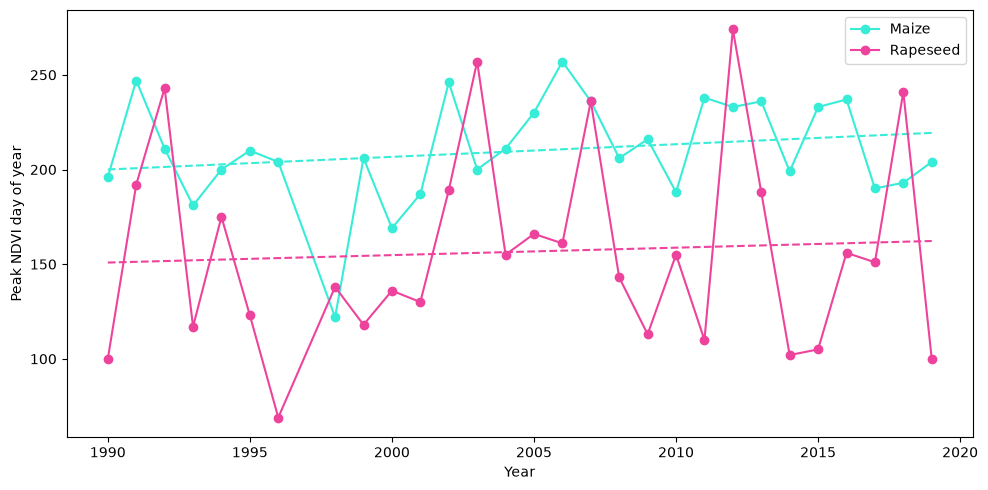

In [40]:
crop_names = ["Maize", "Rapeseed"]

fig, ax = plt.subplots(figsize=(10, 5))

for crop in crop_names:
    g = result[result["crop"] == crop].sort_values("year")
    color = legend_df.loc[legend_df["title"] == crop, "color_hint"].iloc[0]

    ax.plot(g["year"], g["ndvi_peak_doy"], marker="o", color=color, label=crop)

    m, b = np.polyfit(g["year"], g["ndvi_peak_doy"], 1)
    ax.plot(g["year"], m * g["year"] + b, color=color, linestyle="--")

ax.set_xlabel("Year")
ax.set_ylabel("Peak NDVI day of year")
ax.legend()
plt.tight_layout()
plt.show()


## Final takeaway

The main lesson of this workshop is a change in workflow rather than a single Python function. A traditional approach often starts with downloading files and then figuring out how to process them. A cloud-native approach starts with a query: **what data do I need for this analysis?** STAC helps discover the relevant assets, COGs make spatial subsets efficiently accessible, `odc.stac` turns those assets into analysis-ready xarray objects, and Dask lets us postpone and distribute computation.

The result is a workflow that is easier to scale from a small workshop example to larger spatial and temporal analyses. The same principles can be applied to other STAC catalogues, other Earth observation missions, and much larger study areas.